In [1]:
import os
# Imports Python's built-in `os` module.
# We use it here to work with environment variables.


os.environ['KERAS_BACKEND'] = 'torch'
# Sets the environment variable `KERAS_BACKEND` to `torch`.
# This tells Keras to use PyTorch as its backend instead of TensorFlow or JAX.
# Important: this should be set BEFORE importing `keras`.


import keras
# Imports the Keras library.
# Because `KERAS_BACKEND` was set to `torch` before this line,
# Keras should initialize using the PyTorch backend.


print("Keras backend:", keras.backend.backend())
# Calls `keras.backend.backend()` to ask Keras which backend is currently active.
# `print()` displays the result in the terminal.
# Expected output:
# Keras backend: torch

Keras backend: torch


In [2]:
import torch
# Imports the PyTorch library.
# PyTorch provides tensor operations and can use the GPU through CUDA when supported.


torch.cuda.is_available()
# Checks whether PyTorch can currently access a CUDA-capable NVIDIA GPU.
# Returns:
# True  -> CUDA is available and PyTorch can use the NVIDIA GPU.
# False -> PyTorch cannot currently use CUDA.

True

In [3]:
from keras.models import Sequential, Model
from keras.layers import Dense, Input, ReLU, Flatten, Dropout
#pour calculer la loss
from keras.losses import SparseCategoricalCrossentropy
from keras.metrics import Accuracy
# gradient descent optimizer
from keras.optimizers import Adam

from keras.datasets import mnist

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [4]:
def build_model(activation: str = 'relu'):
    model = Sequential([
        Input(shape=(28, 28)),
        Flatten()
        , Dense(264, activation=activation,)
        , Dense(264, activation=activation)
        , Dense(256, activation=activation)
        , Dense(10, activation='softmax')
        #, Dense(1, activation='linear')
        #, Dense(128, activation='relu')
        #, Dense(64, activation='softmax')
        #, ReLU()
    ])

    model.compile(
    optimizer=Adam()
    , loss=SparseCategoricalCrossentropy()
    , metrics=['accuracy']
    )

    return model

model = build_model()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 264)            │       207,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 264)            │        69,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        67,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,610 (1.33 MB)

 Trainable params: 347,610 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

x_train shape: (60000, 28, 28), y_train shape: (60000,)
x_test shape: (10000, 28, 28), y_test shape: (10000,)


In [6]:
model.fit(x_train, y_train
          , batch_size=1024
          , epochs=30
          )


Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5273 - loss: 7.4160
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6755 - loss: 5.0850
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7547 - loss: 3.8202
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8321 - loss: 2.5723
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8716 - loss: 1.9098
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9557 - loss: 0.5620
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9660 - loss: 0.4126
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9714 - loss: 0.3415
Epoch 9/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9754 - loss: 0.2799
Epoch 10/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9797 - loss: 0.2215
Epoch 11/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9821 - loss: 0.1908
Epoch 12/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9842 - lo

In [7]:
model.fit(x_train, y_train, epochs=30
          , batch_size=1024
          , validation_split=0.2)

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9937 - loss: 0.0519 - val_accuracy: 0.9940 - val_loss: 0.0546
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9934 - loss: 0.0519 - val_accuracy: 0.9926 - val_loss: 0.0618
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9946 - loss: 0.0466 - val_accuracy: 0.9929 - val_loss: 0.0606
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9951 - loss: 0.0428 - val_accuracy: 0.9933 - val_loss: 0.0561
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9956 - loss: 0.0387 - val_accuracy: 0.9925 - val_loss: 0.0631
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9963 - loss: 0.0365 - val_accuracy: 0.9920 - val_loss: 0.0663
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9953 - loss: 0.0429 - val_accuracy: 0.9916 - val_loss: 0.0789
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9945 - loss: 0.0480 - val_accuracy: 0.9909 - val_loss:

In [8]:
model.history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

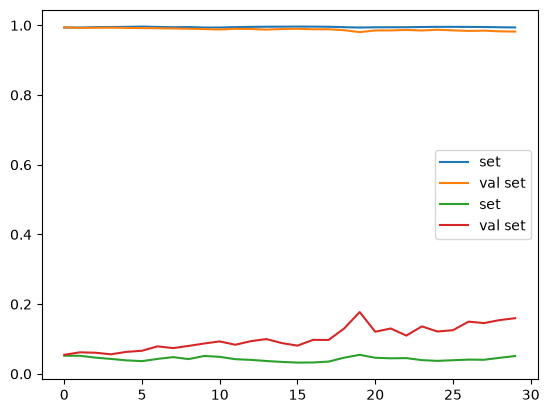

In [9]:
#model.history.history

logs =model.history.history
plt.Figure(figsize=(11, 5))
plt.plot(logs['accuracy'], label = 'set')
plt.plot(logs['val_accuracy'], label = 'val set')

plt.legend()
#plt.show()

logs =model.history.history
#plt.Figure(figsize=(11, 5))
plt.plot(logs['loss'], label = 'set')
plt.plot(logs['val_loss'], label = 'val set')

plt.legend()
plt.show()

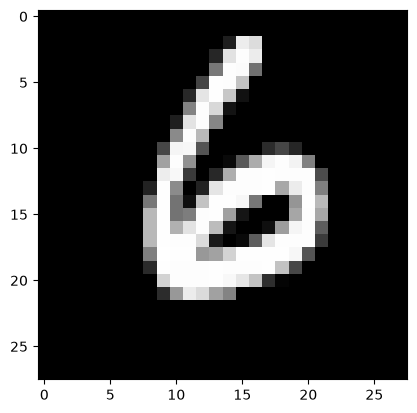

In [10]:
plt.imshow(x_train[21485], cmap='gray')
plt.show()

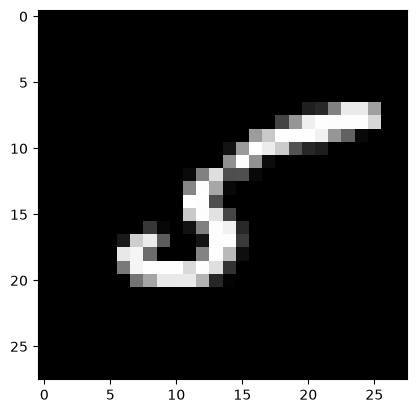

In [11]:
plt.imshow(x_train[11], cmap='gray')
plt.show()

In [12]:
x_train[11]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [13]:
x_train[11].ravel()


array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [14]:
model.fit(x_train, y_train
          , batch_size=1024
          , epochs=10
          )


Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9910 - loss: 0.0724
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9934 - loss: 0.0539
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9937 - loss: 0.0510
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9935 - loss: 0.0522
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9931 - loss: 0.0509
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9954 - loss: 0.0368
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9963 - loss: 0.0325
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9956 - loss: 0.0375
Epoch 9/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9961 - loss: 0.0344
Epoch 10/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9956 - loss: 0.0324
